### Loading processed datasets

In [1]:
import pandas as pd
import numpy as np

X_train = pd.read_csv("../outputs/X_train_processed.csv")
X_test = pd.read_csv("../outputs/X_test_processed.csv")
y_train = pd.read_csv("../outputs/y_train.csv").values.ravel()
y_test = pd.read_csv("../outputs/y_test.csv").values.ravel()

print(X_train.shape, X_test.shape)
print("Fraud rate in train:", y_train.mean())
print("Fraud rate in test:", y_test.mean())

(472432, 2821) (118108, 2821)
Fraud rate in train: 0.03498916246147594
Fraud rate in test: 0.0349933958749619


### Creating Evaluation Function

In [2]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    print(f"===== {model_name} =====")
    print("ROC-AUC:", roc_auc)
    print("PR-AUC:", pr_auc)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)

    return roc_auc, pr_auc

### Training Baseline Model

In [3]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train, y_train)

lr_roc, lr_pr = evaluate_model(lr, X_test, y_test, "Logistic Regression")

C:\Users\katte\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


===== Logistic Regression =====
ROC-AUC: 0.7492720731658323
PR-AUC: 0.1359762572388821

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.64      0.78    113975
           1       0.07      0.71      0.12      4133

    accuracy                           0.64    118108
   macro avg       0.52      0.67      0.45    118108
weighted avg       0.95      0.64      0.75    118108

Confusion Matrix:
 [[72975 41000]
 [ 1218  2915]]


Logistic Regression serves as a weak baseline here. The convergence warning suggests the data needs feature scaling (e.g., StandardScaler) before training linear models.

### Training Decision Tree

In [4]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(class_weight="balanced", random_state=42, max_depth=10)
dt.fit(X_train, y_train)

dt_roc, dt_pr = evaluate_model(dt, X_test, y_test, "Decision Tree")

===== Decision Tree =====
ROC-AUC: 0.8638983179749318
PR-AUC: 0.4163554679235432

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.87      0.92    113975
           1       0.17      0.73      0.27      4133

    accuracy                           0.86    118108
   macro avg       0.58      0.80      0.60    118108
weighted avg       0.96      0.86      0.90    118108

Confusion Matrix:
 [[98877 15098]
 [ 1110  3023]]


### Train Random Forest

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_roc, rf_pr = evaluate_model(rf, X_test, y_test, "Random Forest")

===== Random Forest =====
ROC-AUC: 0.939647621392388
PR-AUC: 0.7305134130662063

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.95      0.39      0.56      4133

    accuracy                           0.98    118108
   macro avg       0.97      0.70      0.77    118108
weighted avg       0.98      0.98      0.97    118108

Confusion Matrix:
 [[113893     82]
 [  2507   1626]]


Random Forest achieved the highest PR-AUC (0.73), significantly outperforming Logistic Regression. This suggests non-linear relationships and interactions between features are crucial for detecting fraud.

### Training XGBoost Model

In [6]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_roc, xgb_pr = evaluate_model(xgb, X_test, y_test, "XGBoost")

===== XGBoost =====
ROC-AUC: 0.9357301752271093
PR-AUC: 0.6499040106498705

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.91      0.95    113975
           1       0.24      0.81      0.37      4133

    accuracy                           0.90    118108
   macro avg       0.62      0.86      0.66    118108
weighted avg       0.97      0.90      0.93    118108

Confusion Matrix:
 [[103389  10586]
 [   769   3364]]


### Creating a model comparison table

In [7]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "ROC-AUC": [lr_roc, dt_roc, rf_roc, xgb_roc],
    "PR-AUC": [lr_pr, dt_pr, rf_pr, xgb_pr]
})

results = results.sort_values(by="PR-AUC", ascending=False)
results

,Model,ROC-AUC,PR-AUC
2,Random Forest,0.939648,0.730513
3,XGBoost,0.935730,0.649904
1,Decision Tree,0.863898,0.416355
0,Logistic Regression,0.749272,0.135976


In [8]:
results.to_csv("../outputs/model_results.csv", index=False)

### Plot Precision-Recall Curve

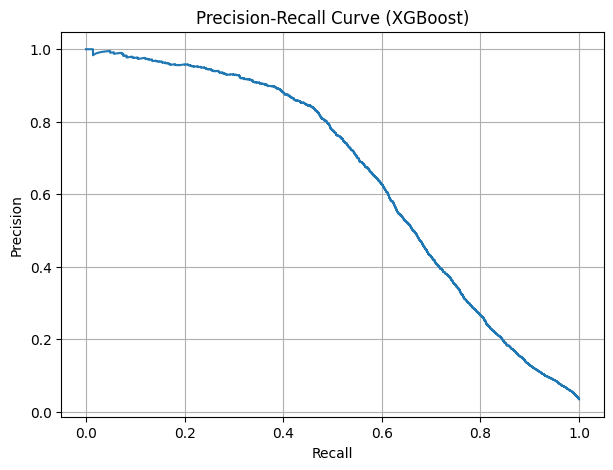

In [9]:
from sklearn.metrics import precision_recall_curve

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)

plt.figure(figsize=(7,5))
plt.plot(recall, precision)
plt.title("Precision-Recall Curve (XGBoost)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.show()

### Feature Importance Plot

In [10]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance.head(15)

,Feature,Importance
295,V258,0.092629
255,V218,0.074155
107,V70,0.066385
128,V91,0.063934
238,V201,0.055409
331,V294,0.022040
17,C8,0.010802
139,V102,0.009729
531,M4_Missing,0.008156
23,C14,0.008108


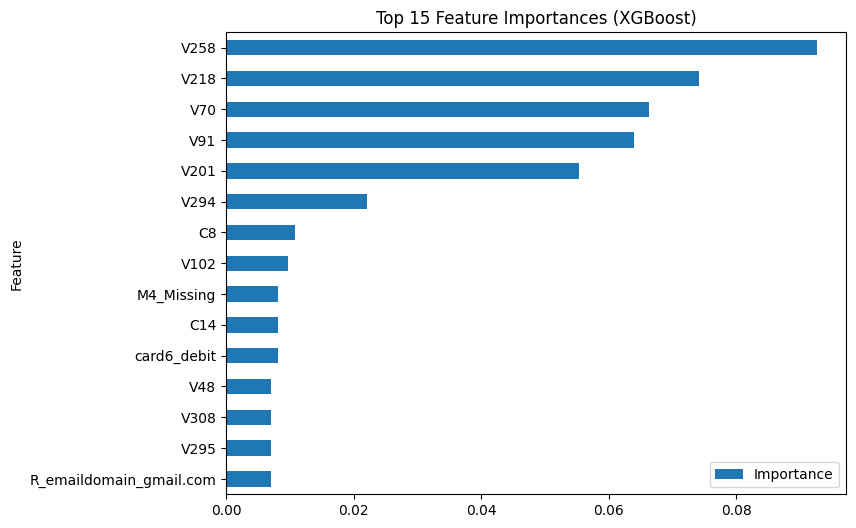

In [11]:
importance.head(15).set_index("Feature").plot(kind="barh", figsize=(8,6))
plt.title("Top 15 Feature Importances (XGBoost)")
plt.gca().invert_yaxis()
plt.show()

In [13]:
importance.to_csv("../outputs/feature_importance.csv", index=False)

Research Question:

Does transaction + identity improve fraud detection compared to amount alone?

In [14]:
X_train_amt = X_train[["TransactionAmt", "TransactionAmt_log"]]
X_test_amt = X_test[["TransactionAmt", "TransactionAmt_log"]]

lr_amt = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_amt.fit(X_train_amt, y_train)

amt_roc, amt_pr = evaluate_model(lr_amt, X_test_amt, y_test, "TransactionAmt Only Model")

===== TransactionAmt Only Model =====
ROC-AUC: 0.5333840025342915
PR-AUC: 0.043679927006334676

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.69      0.81    113975
           1       0.04      0.39      0.08      4133

    accuracy                           0.68    118108
   macro avg       0.51      0.54      0.44    118108
weighted avg       0.94      0.68      0.78    118108

Confusion Matrix:
 [[79154 34821]
 [ 2535  1598]]


Using only transaction amount performs poorly for fraud detection. The model generates a large number of false alarms and achieves very low precision and PR-AUC. This suggests that transaction amount alone is not sufficient and that additional transaction metadata and identity features are necessary for effective fraud detection.

Threshold Tuning

In [15]:
from sklearn.metrics import precision_score, recall_score

threshold = 0.2
y_pred_thresh = (y_prob_xgb >= threshold).astype(int)

print("Precision:", precision_score(y_test, y_pred_thresh))
print("Recall:", recall_score(y_test, y_pred_thresh))

Precision: 0.0836157234835649
Recall: 0.9552383256714251


Lowering the threshold to 0.2 catches almost all fraud (95% recall) but results in many false positives (8.3% precision). In a real business case, we would need to balance the cost of manual review vs. the cost of fraud.